Lasso and Elastic Net Regressions

This notebook presents a simple implementation of Lasso and elastic net regressions. It uses the [OSQP.jl](https://github.com/osqp/OSQP.jl) package for the numerical optimisation, rather than a tailor-made algorithm.

The purpose of using the Lasso and EN regressions is here to help with the model selection. These methods are useful for indicating which variables that are most important. With this variable selection done, we might choose to apply OLS on the chosen set of regressors.

## Load Packages and Extra Functions

The key function for the LASSO/ridge/Elastic Net regressions is from the (local) `FinEcmt_Lasso` module. 

In [1]:
MyModulePath = joinpath(pwd(),"src")
!in(MyModulePath,LOAD_PATH) && push!(LOAD_PATH,MyModulePath)
using FinEcmt_OLS, FinEcmt_Lasso

In [2]:
#=
include(joinpath(pwd(),"src","FinEcmt_OLS.jl"))
include(joinpath(pwd(),"src","FinEcmt_Lasso.jl"))
using .FinEcmt_OLS, .FinEcmt_Lasso
=#

In [3]:
using Dates, DelimitedFiles, LinearAlgebra

In [4]:
using Plots, LaTeXStrings
default(size = (480,320),fmt = :png)

# Loading Data

on monthly realized standard deviation for S&P500 (calculated from daily data) and regressors used to predict it. 

In [5]:
(xx,header) = readdlm("Data/ModelSelectData.csv",',',header=true)

dN    = Date.(xx[:,1],"yyyy-mm-dd")                   #convert to Date
(y,x) = (Float64.(xx[:,2]),Float64.(xx[:,3:end]))     #dependent variable, regressors

(yName,xNames) = (header[2],vec(header[3:end]))

T = length(y)

println("Dependent variable: $yName \n")
println("Regressors: ")
printmat(xNames)

Dependent variable: ln std 

Regressors: 
ln std(-1)
ln std(-2)
ln VIX(-1)
ln VIX(-2)
     R(-1)
     R(-2)



# An Elastic Net Regression

minimizes a combination of the Lasso and Ridge regression loss functions

$(Y-Xb)'(Y-Xb)/T + \gamma \sum |b_i-\beta_{i0}| + \lambda \sum (b_i-\beta_{i0})^2$, 

where $\beta_{i0}$ is the target for coefficient $i$ (defaults to 0). Set $\lambda=0,\gamma>0$ to get a *Lasso* regression or instead $\lambda>0,\gamma=0$ to get a *ridge* regression.

Notice that we divide the sum of squared residuals by $T$. This helps the interpretation of the $\gamma$ and $\lambda$ values.

The problem is reformulated (see the code below) as a linear-quadratic problems with restrictions (see below). The code uses the `OSQP.jl` solver.

The function `LassoEN()`  (included above) implements this.

In [6]:
#@doc LassoEN

@doc2 LassoEN

```julia
LassoEN(Y,X,γM=0,λ=0,β₀=0)
```

Do Lasso (set γ>0,λ=0), ridge (set γ=0,λ>0) or elastic net regression (set γ>0,λ>0). The function loops over the values in a vector γM, but requires λ to be a number (scalar).

### Input

  * `Y::Vector`:: T-vector, zero mean dependent variable
  * `X::Matrix`:  TxK matrix, zero mean regressors
  * `γM::Vector`: nγ-vector with different values of γ (could also be a number)
  * `λ::Number`:  value of λ (a number)
  * `β₀::Vector`: K-vector of target levels for the coeffs (could also be a common number)

### Remark (details on the coding)

Choice variables `z = [b;t]` with lengths K and K respectively

The objective

`0.5*z'P*z + q'z`

effectively involves

`0.5*z'P*z =  b'(X'X/T+λI)b` and

`q'z = (-2X'Y/T-2λβ₀)'b + γ1't`

The restrictions `lb <= Az <= ub` imply

`-∞ <= β-t    <= β₀`

`β₀ <= β-t    <= ∞`

### Requires

using OSQP, SparseArrays, LinearAlgebra


In [7]:
#using CodeTracking
#println(@code_string LassoEN([1],[1],0.1))    #print the source code

# Lasso Regression

The next cell makes a Lasso regression for a single value of γ. The dependent variable is the (return of the) first mutual fund in `RFunds` (see data loading) and the regressors are (returns on) a number of benchmark portfolios (again, see data loading).

The data is standardised to have zero mean and unit variance before the estimation, by using the `StandardiseYX()` function (included above).

In [8]:
(Y,X) = StandardiseYX(y,x)

γ = 10^(-1.5)
(b,b_ls) = LassoEN(Y,X,γ)

printblue("OLS and Lasso coeffs (with γ=$(round(γ,digits=3))):\n")
printmat(b_ls,b;colNames=["OLS","Lasso"],rowNames=xNames,width=15)

OLS and Lasso coeffs (with γ=0.032):

                      OLS          Lasso
ln std(-1)          0.158          0.146
ln std(-2)          0.039          0.006
ln VIX(-1)          0.609          0.594
ln VIX(-2)         -0.042          0.000
R(-1)              -0.051         -0.047
R(-2)               0.003         -0.000



# Redo the Lasso Regression with Different γ (gamma) Values

The function `LassoEN()` can loop over $\gamma$ values (and exploit the fact that this only requires a partial updating of the problem).

You can also change the target level $\beta_0$ to be something else than zero.

In [9]:
nγ = 51
γM = range(0.01,1,length=nγ)
β₀ = 0.0     #change to eg. 0.1 to set another target, or specify a vector

bLasso, = LassoEN(Y,X,γM,0,β₀);
#printmat([γM bLasso'])

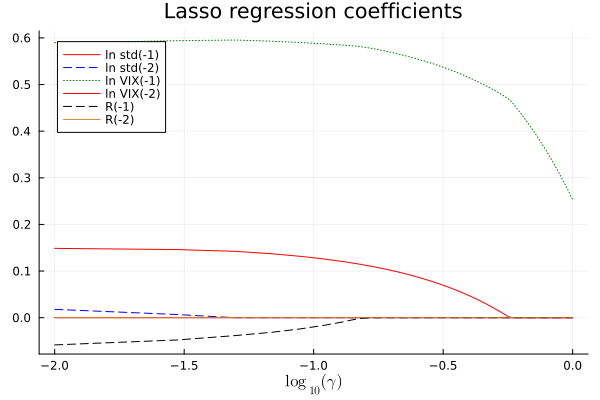

In [10]:
p1 = plot( log10.(γM),bLasso',
           title = "Lasso regression coefficients",
           color = [:red :blue :green :red :black :peru],
           linestyle = [:solid :dash :dot :solid :dash :solid],
           xlabel = L"\log_{10}(\gamma)",
           label = permutedims(xNames),
           legend = :topleft,
           size = (600,400) )
display(p1)

# A Ridge Regression

minimizes 

$(Y-Xb)'(Y-Xb)/T +  \sum \lambda_i (b_i-\beta_{i0})^2,$

where $\beta_{i0}$ is the target for coefficient $i$ (defaults to 0) and $\lambda_i$ the penalty on deviations from the target. We compare the results from using linear algrebra and optimization based ones from the `LassoEN()` function. A function for this is included above.

In [11]:
β₀ = 0              #change to eg. 0.1 to set another target

b_LS     = X\Y
b_ridge  = RidgeRegression(Y,X,0.1,β₀)
b_ridge2, = LassoEN(Y,X,0,0.1,β₀)

printblue("OLS and ridge regression:\n")
printmat(b_ls,b_ridge,b_ridge2;colNames=["OLS","analytical ridge","numerical ridge"],rowNames=xNames,width=20)

OLS and ridge regression:

                           OLS    analytical ridge     numerical ridge
ln std(-1)               0.158               0.186               0.186
ln std(-2)               0.039               0.055               0.055
ln VIX(-1)               0.609               0.415               0.415
ln VIX(-2)              -0.042               0.080               0.080
R(-1)                   -0.051              -0.108              -0.108
R(-2)                    0.003               0.014               0.014



In [12]:
nλ = 51
λM = range(0,10,length=nλ)

bridge   = fill(NaN,size(X,2),nλ)
for i in 1:nλ                          #loop over λ values
    bridge[:,i] = RidgeRegression(Y,X,λM[i])
end

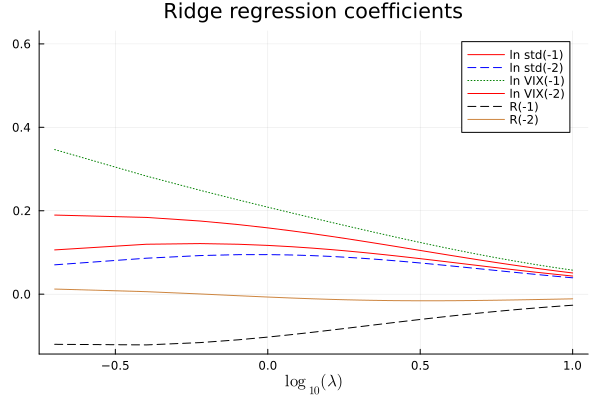

In [13]:
p1 = plot( log10.(λM),bridge',
           title = "Ridge regression coefficients",
           color = [:red :blue :green :red :black :peru],
           linestyle = [:solid :dash :dot :solid :dash :solid],           
           xlabel = L"\log_{10}(\lambda)",
           label = permutedims(xNames),
           size = (600,400) )
display(p1)

# An Elastic Net Regression

In [14]:
λ = 0.2
bEN, = LassoEN(Y,X,γM,λ);

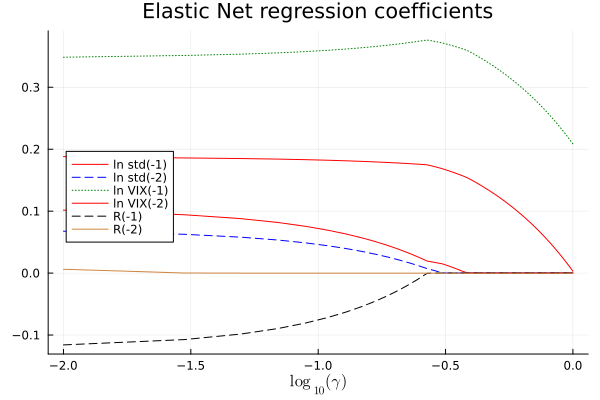

In [15]:
p1 = plot( log10.(γM),bEN',
           title = "Elastic Net regression coefficients",
           color = [:red :blue :green :red :black :peru],
           linestyle = [:solid :dash :dot :solid :dash :solid],                      
           xlabel = L"\log_{10}(\gamma)",
           label = permutedims(xNames),
           legend = :left,
           size = (600,400) )
display(p1)

# OLS on the Most Important Variables

The Lasso approach suggests that some regressors are much more important than others. We now apply OLS to this set.

In [16]:
vv = [1,3]
(Y,X) = (y,[x[:,vv] ones(T)])

(b,_,_,V,) = OlsGM(Y,X)
RegressionTable(b,V,vcat(xNames[vv],"c"))

                coef    stderr    t-stat   p-value
ln std(-1)     0.156     0.061     2.563     0.010
ln VIX(-1)     0.888     0.086    10.264     0.000
c             -0.387     0.146    -2.651     0.008

